In [21]:
import numpy as np 
import os 
from pathlib import Path
if Path.cwd().name == "data":
    os.chdir("..")

In [22]:
from data.mvtec_loading import get_dataloaders

In [23]:
from utils import read_config
config = read_config("configs/test.yaml")
print(config)

namespace(data={'dataset_root': '/home/hakimmics/data/mvtec_anomaly_detection', 'category': 'cable', 'img_size': 128, 'batch_size': 16, 'num_workers': 2, 'pin_memory': True})


In [24]:
from types import SimpleNamespace

data_config = SimpleNamespace(**config.data)
train_loader, test_loader, train_dataset, test_dataset = get_dataloaders(data_config)

In [25]:
print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

# Check one batch
x, y = next(iter(train_loader))

print("Batch image shape:", x.shape)
print("Batch label shape:", y.shape)
print("Image dtype:", x.dtype)
print("Label dtype:", y.dtype)

print("Image min:", x.min().item())
print("Image max:", x.max().item())

print("Labels:", y[:10])

Train dataset size: 224
Test dataset size: 150
Train batches: 14
Test batches: 10


Batch image shape: torch.Size([16, 3, 128, 128])
Batch label shape: torch.Size([16])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -0.9372549057006836
Image max: 1.0
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [26]:
print("Train classes:", train_dataset.classes)
print("Train class_to_idx:", train_dataset.class_to_idx)

print("Test classes:", test_dataset.classes)
print("Test class_to_idx:", test_dataset.class_to_idx)

Train classes: ['good']
Train class_to_idx: {'good': 0}
Test classes: ['bent_wire', 'cable_swap', 'combined', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']
Test class_to_idx: {'bent_wire': 0, 'cable_swap': 1, 'combined': 2, 'cut_inner_insulation': 3, 'cut_outer_insulation': 4, 'good': 5, 'missing_cable': 6, 'missing_wire': 7, 'poke_insulation': 8}


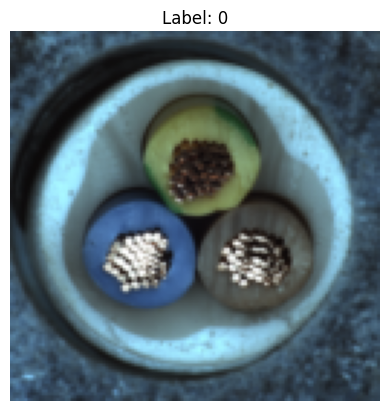

In [27]:
import torch
import matplotlib.pyplot as plt

img, label = train_dataset[0]

# unnormalize: [-1, 1] -> [0, 1]
img_show = img * 0.5 + 0.5
img_show = img_show.clamp(0, 1)

plt.imshow(img_show.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()